In [1]:
from pyfiles.ftsteane import *
from HPC.Upload.classes import *
from random import choices
import cirq
import itertools

In [ ]:
0.25666666666666665
0.013547413310569939

In [ ]:
y, sigma = avg15_coin("rotsurf9", 3, 0.005, True, k=20)
print(y) 
print(sigma)

0.27291666666666664
0.014227300796811839


In [13]:
dustin = RotSurf9q(2)

dustin.h(0)
dustin.rz_cheat(np.pi/6,0)
dustin.h(0)

dustin.readout(0,1000,0)
print("Preselection: ", dustin.preselected)
print("Postselected: ", dustin.post)
print("Zeros: ", dustin.zeros)
print("Ones: ", dustin.ones)
print("Selected zeros:", dustin.zeros/(dustin.zeros+dustin.ones))

Preselection:  0
Postselected:  0.0
Zeros:  0.938
Ones:  0.062
Selected zeros: 0.938


In [2]:
letters = ["I", "X", "Z"]

combinations = list(itertools.product(letters, repeat=11))

print(np.shape(combinations))

print(combinations[0])

counts = np.array([
    [c.count("I"), c.count("X"), c.count("Z")]
    for c in combinations
])

print(counts[0])

#np.save("Adapted Noise Channel/counts.npy", counts)

(177147, 11)
('I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I')
[11  0  0]


In [30]:
probs = []
p_error = 0.01              #1% error for X error to happen and Z-error individually, i.e. total error rate of e.g. 2% per gate
for i in combinations:
    hmm = 1
    for j in i:
        if j == "X":
            hmm = hmm*p_error
        elif j == "Z":
            hmm = hmm*p_error
        else:
            hmm = hmm*(1-2*p_error)
    probs.append(hmm)

In [32]:
np.savetxt("Adapted Noise Channel/probabilities_0_01.txt", probs)

In [8]:
letters = ["I", "X", "Z"]

combinations = list(itertools.product(letters, repeat=11))

def error(poss: int, comb: list):
    pos = poss-1
    if poss <= 7:
        if comb[pos] == "X":
            return cirq.X(q0)
        elif comb[pos] == "I":
            return cirq.I(q0)
        elif comb[pos] == "Z":
            return cirq.Z(q0)
    elif poss == 8:
        if comb[pos] == "X":
            return cirq.X(q1)
        elif comb[pos] == "I":
            return cirq.I(q1)
        elif comb[pos] == "Z":
            return cirq.Z(q1)
    elif poss == 9:
        if comb[pos] == "X":
            return cirq.X(q2)
        elif comb[pos] == "I":
            return cirq.I(q2)
        elif comb[pos] == "Z":
            return cirq.Z(q2)
    elif poss == 10:
        if comb[pos] == "X":
            return cirq.X(q3)
        elif comb[pos] == "I":
            return cirq.I(q3)
        elif comb[pos] == "Z":
            return cirq.Z(q3)
    elif poss == 11:
        if comb[pos] == "X":
            return cirq.X(q4)
        elif comb[pos] == "I":
            return cirq.I(q4)
        elif comb[pos] == "Z":
            return cirq.Z(q4)

results = []

for i, val in enumerate(combinations):
    q0, q1, q2, q3, q4 = cirq.LineQubit.range(5)
    circuit = cirq.Circuit()

    circuit.append([
        error(1,val),
        cirq.H(q0),
        error(2,val),
        cirq.S(q0)**(-1),
        error(3,val), 
        cirq.CNOT(q1, q0),
        error(8,val),
        error(4,val),
        cirq.CNOT(q2, q0),
        error(9,val),
        error(5,val),
        cirq.CNOT(q3, q0),
        error(10,val),
        error(6,val),
        cirq.CNOT(q4, q0),
        error(11,val),
        error(7,val)
    ])
    U = cirq.unitary(circuit)
    arr1 = np.sqrt(2)*U[:16,:16]
    results.append(arr1)
    # if i == 0:
    #     np.savez("Adapted Noise Channel/16q_error_channel_S.npz", arr1)
    # else:
    #     data = np.load("Adapted Noise Channel/16q_error_channel_S.npz")
    #     arrays = [data[key] for key in data.files]
    #     arrays.append(arr1)
    #     np.savez("Adapted Noise Channel/16q_error_channel_S.npz", *arrays)

arr = np.array(results)   # shape: (177147, 16, 16)
#np.save("Adapted Noise Channel/16q_error_channel_Sdg.npy", arr)


In [2]:
# load npz
with np.load("Adapted Noise Channel/16q_error_channel_S.npz") as data:
    arrays = [data[key] for key in data.files]

# stack into one big array
big_array = np.stack(arrays)

# save as npy
np.save("Adapted Noise Channel/16q_error_channel_S.npy", big_array)

In [13]:
arr = np.load("Adapted Noise Channel/16q_error_channel_S.npy")
prob = np.load("Adapted Noise Channel/counts.npy")

print(prob[0])

[11  0  0]


In [18]:
test = inv_covert(16,8)

print(test)

00010000


In [2]:
n = 15
angle = np.linspace(0,1,n+2)
angle = np.delete(angle, [n+1])
angle = np.delete(angle, [0])
print(angle)

[0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375]


In [13]:
file = np.loadtxt("cirq_state_gpu_qiskit_order_reduced_daigonal.txt")

file1 = np.loadtxt("cirq_state_cpu_qiskit_order_reduced_daigonal.txt")

bitstrings, prob, prob1 = [], [], []

for i, val in enumerate(file):
    bitss = inv_covert(i, 16)
    bitstrings.append(bitss)
    prob.append(val**2)
    prob1.append(file1[i]**2)

code0 = ['0110010100110000', '1111000001100110', '1111001101010101', '0011110011000011', '0011001100110000', '0011001100111111', '1001011001101001', '0011111110010101', '0101011001100110', '0000000000001111', '1010010100111100', '1010010101010101', '0011001101011001', '1100111110011010', '1100111110010101', '1100001101010110', '1111110010100110', '0101010100111100', '1010100110011010', '1010011001100101', '0011000001100101', '1111110011001100', '1100111110011001', '1100000001100101', '0000111111111111', '0011000000000011', '1001100110010101', '0110010101010110', '1010010100110011', '1010101011001100', '1001011001100101', '0000001101010110', '0101101011000000', '0011001101011010', '0000110010100110', '1001101010100101', '0000000000000011', '0011111111110000', '1010010101010110', '0110011001100110', '1111111111111100', '1100001100110011', '1010101011000000', '0000000001100101', '0110100110011001', '1001011001100110', '0011001100111100', '0101100110011001', '1100110010100101', '0011110010101001', '0101010100110011', '0110100111111100', '1100001101011001', '1100110010101001', '0000001100111111', '1010101010100101', '1001010100110000', '1100111111110011', '0110101011000000', '0101100110010101', '0101011001100101', '0000111110011010', '0000001100110000', '1010101010101001', '0000001101011010', '1001101010101001', '1111110011000011', '1001101011000000', '0101011001101010', '0101100110010110', '1111110010101010', '0110010100111100', '1100000000000000', '1001010101011010', '0110100110010101', '1010101011000011', '0101101011001100', '0110101011001111', '0110011000001100', '0110101010100110', '0110100110010110', '1100000000001111', '0101101010100101', '0110011000001111', '0000111110010110', '0011000000001111', '1010011000000000', '0110100111110011', '1100001101011010', '1001011001101010', '1010100111111100', '0011111111111111', '1010010101011001', '0000001101011001', '1111000000000000', '0101010101011001', '1100111110010110', '1100000000001100', '1001101010100110', '0011111110010110', '0000110010101010', '0101010100111111', '0011111110011010', '1010011000001100', '1001010100111100', '0000000001101010', '0000111111110011', '0110100111110000', '1001010101011001', '1100110010101010', '0110011001101010', '0101100111110011', '1010100111110011', '1001011000000011', '0101011000001100', '0000001100110011', '1001100111110011', '0000110011001100', '0011110011001111', '0011111110011001', '0101101010101010', '1111111110011001', '0011001100110011', '1001011000001111', '1010101010100110', '1100110011001100', '0101101010100110', '1010011000000011', '1111001100111100', '0101101011001111', '0101100111111100', '0101100110011010', '0110010100111111', '1010100110010110', '0000001100111100', '0110101010101001', '1001010101010110', '1010011001101001', '1001100111110000', '1001100110011010', '0000000000000000', '1111001101011010', '0101011000000000', '1111001101010110', '1100110011000011', '0101100111111111', '0000111111111100', '0110011000000000', '1010100111111111', '0011110011001100', '0110011001100101', '1010010100110000', '0101101011000011', '1100000001100110', '1010010101011010', '0110101011000011', '1100110010100110', '0110100111111111', '1111000001100101', '1010101011001111', '0000001101010101', '0110010101011010', '1111110010100101', '0000110011001111', '0110100110011010', '0110101010100101', '1111001100110011', '0101011000001111', '1111111110010101', '1001101011000011', '1100001101010101', '0011111111110011', '1010100111110000', '1001010101010101', '1001100110010110', '0101010100110000', '1111001100110000', '1111110010101001', '1001100111111111', '1001011000000000', '1001010100111111', '1010011001100110', '0011110010100101', '0110010100110011', '1010011001101010', '0000111110010101', '1100000001101001', '0101011000000011', '1100111111111111', '1111110011000000', '0000000001101001', '1001101011001100', '0110010101010101', '0101010101010101', '1111000001101010', '1111111111110011', '1111000000001111', '1010010100111111', '0011000001100110', '0101101010101001', '0011000000000000', '1111001100111111', '0110010101011001', '0000000000001100', '1001101011001111', '0011110010100110', '0101100111110000', '0011110010101010', '0000110011000011', '1010011000001111', '0101010101010110', '0101011001101001', '1111000001101001', '1001010100110011', '1100001100111100', '0011000000001100', '0011110011000000', '1100000001101010', '0011001101010110', '0000111110011001', '1100110011000000', '1100000000000011', '1100111111111100', '1111001101011001', '0011000001101010', '1100111111110000', '1001101010101010', '1111111110010110', '0011111111111100', '1111110011001111', '1010100110011001', '1111111111111111', '0110011000000011', '1111111111110000', '1100110011001111', '1111000000000011', '0110011001101001', '1100001100111111', '0011000001101001', '1001100111111100', '0000110010101001', '1001100110011001', '0101010101011010', '1100001100110000', '0011001101010101', '0000110011000000', '1001011000001100', '1010100110010101', '1010101010101010', '0110101010101010', '0000111111110000', '0110101011001100', '0000000001100110', '1111111110011010', '0000110010100101', '1111000000001100']
code1 = ['0111100011101110', '0111100010001011', '0100100011101110', '0010000100011110', '1101111011100010', '0100011101110111', '0010110111010001', '0111100011101101', '1110000101111011', '1101110110111011', '0001111010001000', '0001110111011101', '1101001001000111', '0010111010000111', '1101000101110100', '1000010000101110', '0111010000101110', '0001110110111011', '1101111010000111', '1011010000101101', '0100011101111011', '1000100011101110', '0111101110111011', '1101001000101101', '1101000101111000', '1101110111010010', '0010000101110111', '0010001000100010', '1000101111011101', '0001111011101110', '0010000101110100', '1011100011101110', '1110110111010010', '0001110110110111', '1110111011101101', '1110111011100001', '0010001000101110', '1101111010000100', '0111011100011110', '1101001001001011', '1110001000100010', '1101111011101101', '1101110111010001', '1000011101111000', '0111011100010010', '0111010000100010', '0100101110111000', '0111010000100001', '1011101110111000', '0001111010000111', '1011100011100001', '1101111010001011', '0001001000101110', '0111011101110111', '1011011100010001', '1110000100011110', '1011101110110111', '1110110110111011', '1000101110111000', '0100011100010001', '0010111010001000', '0111011101111000', '0010110110110111', '0010111010000100', '1000101110111011', '0100011100011110', '1000100010001011', '0111100010000111', '1110000101111000', '1101000100010010', '1000011100010001', '0010001001001011', '1110111010001000', '1101111011101110', '1101000101110111', '0100010001000100', '0010110110110100', '1000011100011101', '1011101111010010', '1011101111010001', '1000100011101101', '1110000101110100', '1011011101111000', '1101000101111011', '1011100010001000', '0111011100011101', '0100100010000111', '0010111011100010', '0111100010000100', '1110000101110111', '1110111011101110', '1110001000100001', '0001000101111000', '1101110111011110', '1110111011100010', '1000010000100010', '0010000100010010', '1000100011100010', '0100011101111000', '1011011100011110', '0010111010001011', '1011010001001011', '1011011100011101', '0001110110110100', '1110111010001011', '1011010001000100', '0100011100010010', '1000100010000100', '0111010001000111', '1101000100011110', '1011101111011110', '0010000101111011', '1000100010001000', '1110001000101101', '0001000100010001', '1000101110110111', '0010111011101110', '0100101111011101', '0001111010000100', '1000101111011110', '0100101110111011', '0001000100011110', '1110111010000111', '1110001001000111', '1110110110111000', '1101001000100010', '1011010000101110', '1110000100011101', '0111101110110100', '0100010000101110', '0001001001001011', '0111011101111011', '1000010001000100', '1110111010000100', '1110110111011101', '0111010000101101', '1101001001000100', '1000010000100001', '1011010001001000', '0010001000101101', '0001001000101101', '1000010000101101', '0001001001000100', '1000101111010010', '0100101111010001', '1110001000101110', '0100101111010010', '0100100010001011', '0111101110110111', '0111100011100010', '0010110111011110', '1000011101110111', '0001000101110100', '1000101111010001', '0111010001001011', '0100100011100010', '1000011100011110', '0100011101110100', '0001000100011101', '1101000100011101', '1101110110111000', '0001110111010001', '1110110111010001', '0010110110111011', '1011100011100010', '1000011101111011', '0100011100011101', '0100010000100010', '0001111011100010', '0010000100010001', '0001001000100001', '0001001001000111', '0100100011100001', '1000100011100001', '1110000100010010', '1011010000100001', '0111101111010010', '0100010000101101', '0111010001000100', '0111011101110100', '1000100010000111', '1101001000100001', '0100101111011110', '0010110111010010', '0010111011101101', '0001000101111011', '0100010001000111', '0100010001001000', '0111011100010001', '0001001000100010', '0010001001001000', '1011101111011101', '1101111011100001', '0111101111011101', '0100101110110100', '1101001001001000', '1110001001001011', '0111101110111000', '0010001001000111', '0010110111011101', '1011010001000111', '1000010001001000', '1110110111011110', '0001000101110111', '0010001000100001', '1011011101110111', '0100010000100001', '0010111011100001', '1110001001000100', '1011010000100010', '1110000100010001', '1101110111011101', '0111101111011110', '1011100010000100', '1011011101111011', '0100010001001011', '0111100010001000', '1011011100010010', '1101000100010001', '0100100011101101', '0111100011100001', '0001111011101101', '0111101111010001', '0001110110111000', '1000010001000111', '0001110111011110', '0010001001000100', '0100101110110111', '0010110110111000', '1000101110110100', '1000010001001011', '1101111010001000', '1011101110110100', '0001110111010010', '1101110110110100', '1000011101110100', '0001111011100001', '0001001001001000', '1000011100010010', '0001111010001011', '1011100011101101', '1101001000101110', '0100100010000100', '1011101110111011', '0100100010001000', '1011011101110100', '0010000100011101', '1110110110110100', '1011100010000111', '0010000101111000', '1110001001001000', '1110110110110111', '0111010001001000', '1011100010001011', '1101110110110111', '0001000100010010']

In [ ]:
# code0 = ['000110101', '110110110', '110110101', '110000000', '000110110', '101101101', '011101101', '011011000', '011011011', '110000011', '000000000', '011101110', '101011011', '101101110', '000000011', '101011000']
# code1 = ['010100111', '010010001', '111111111', '001001010', '111001010', '001111111', '100010010', '111111100', '100100100', '100010001', '001001001', '010010010', '100100111', '111001001', '001111100', '010100100']

In [ ]:
# with open("RotSurf9q_1.txt", "w", encoding="utf-8") as f:
#     for item in code1:
#         f.write(item + "\n")

In [14]:
zero, one, err = 0,0,0
for i in range(1000):
    sample = choices(bitstrings, prob1)
    if sample[0] in code0:
        zero += 1
    elif sample[0] in code1:
        one += 1
    else:
        err += 1

print("Zero: ", zero)
print("One: ", one)
print("Error: ", err)

Zero:  0
One:  147
Error:  853


In [5]:
tot = 0
count = 0
for i, val in enumerate(file):
    if val > 0.01:
        count += 1
    tot += val**2
print(tot)
print(count)

1.000000121188234
2048


In [8]:
ok, errr = avg15_coin("rotsurf9", 3, noise=0.001, qec=False,k=1)

In [9]:
print(ok, errr)

0.225 0.07378647873726217


In [2]:
ok, errr = avg15_coin("rotsurf9", 3, noise=0.001, qec=True,k=1)

In [3]:
print(ok, errr)

0.10833333333333334 0.03088209357708288


In [4]:
dustin = Steane7q(1)

dustin.postselection = True

dustin.h(0)
for i in range(1):
     dustin.t_ghz(0)
# dustin.qec(0)
#dustin.s_ghz(0)
dustin.h(0)

#dustin.qec(0)
# dustin.qec(0)

dustin.readout(0,1000,0.00)

print("Preselection: ", dustin.preselected)
print("Postselected: ", dustin.post)
print("Zeros: ", dustin.zeros)
print("Ones: ", dustin.ones)
print("Selected zeros:", dustin.zeros/(dustin.zeros+dustin.ones))

{'1001100 1 000000 000': 5, '0100101 0 000000 000': 4, '0100101 1 000000 000': 9, '0101010 1 000000 000': 9, '0110011 0 000000 000': 61, '0000000 0 000000 000': 62, '1110000 1 000000 000': 13, '1000011 0 000000 000': 8, '1011010 0 000000 000': 46, '1100110 0 000000 000': 42, '0010110 0 000000 000': 9, '1101001 0 000000 000': 60, '1111111 0 000000 000': 10, '0111100 0 000000 000': 62, '1110000 0 000000 000': 9, '1011010 1 000000 000': 47, '1100110 1 000000 000': 59, '0011001 1 000000 000': 13, '1101001 1 000000 000': 54, '0110011 1 000000 000': 57, '0001111 0 000000 000': 39, '1000011 1 000000 000': 12, '0011001 0 000000 000': 9, '1010101 1 000000 000': 49, '0000000 1 000000 000': 55, '1111111 1 000000 000': 11, '0111100 1 000000 000': 44, '0101010 0 000000 000': 10, '1010101 0 000000 000': 57, '1001100 0 000000 000': 6, '0001111 1 000000 000': 60, '0010110 1 000000 000': 9}
Preselection:  0.0
Postselected:  0.0
Zeros:  0.854
Ones:  0.146
Selected zeros: 0.854


In [2]:
ok, errr = avg15_coin("rotsurf9", 3, noise=0.001, qec=False,k=1)

print(ok)
print(errr)

0.16666666666666666
0.06028481781725196


In [7]:
n = 15
angle = np.linspace(0,1,n+2)
angle = np.delete(angle, [n+1])
angle = np.delete(angle, [0])

print(angle)

neighbours = [closest_bitstring(i, 3) for i in angle]
print(neighbours)

fake = [convert(i) for i in neighbours]

print(fake)

[0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375]
['000', '001', '001', '010', '010', '011', '011', '100', '100', '101', '101', '110', '110', '111', '111']
[0, 0.125, 0.125, 0.25, 0.25, 0.375, 0.375, 0.5, 0.5, 0.625, 0.625, 0.75, 0.75, 0.875, 0.875]


In [ ]:
y = avg14_coin_success("steane", 3, noise=0.00, qec=False, k=1)

print(y)

In [ ]:
T_alt = np.diag([1, (1+1j)/np.sqrt(2), (1+1j)/np.sqrt(2), 1,
            (1+1j)/np.sqrt(2), 1, 1, (1+1j)/np.sqrt(2),
            (1+1j)/np.sqrt(2), 1, 1, (1+1j)/np.sqrt(2),
            1, (1+1j)/np.sqrt(2), (1+1j)/np.sqrt(2), 1])
        #threshold = 1e-10
        #T_alt[np.abs(T_alt) < threshold] = np.nan
t_timo = UnitaryGate(T_alt, label="t_timo")

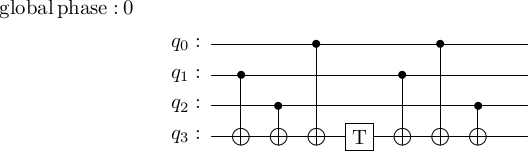

In [ ]:
qc = QuantumCircuit(4)

qc.append(t_timo, [0, 1, 2, 3])

new_qc = transpile(qc, basis_gates=["h", "t", "cx"], optimization_level=3)

qc.draw("mpl")

new_qc.draw("latex")

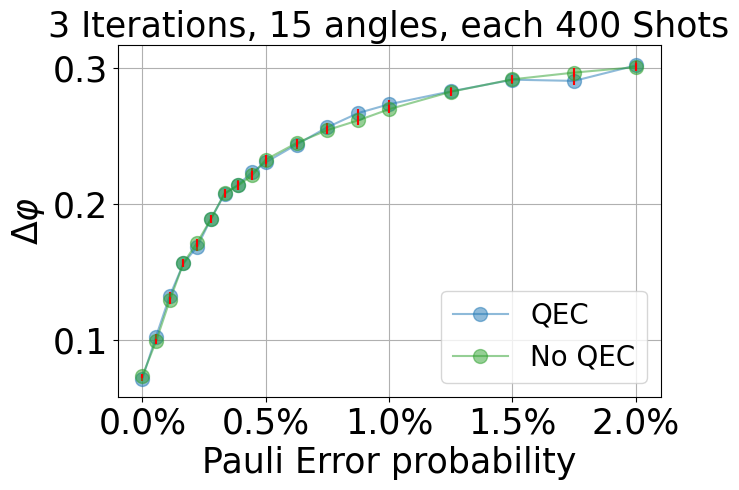

In [7]:
#x, y, y_qec, err, err_qec = [],[],[],[],[]
x1, y1, y_qec1, err1, err_qec1 = np.loadtxt("text/RotSurfFinal_a.txt", delimiter = ",")
x2, y2, y_qec2, err2, err_qec2 = np.loadtxt("text/RotSurfFinal_a+.txt", delimiter = ",")
x3, y3, y_qec3, err3, err_qec3 = np.loadtxt("text/RotSurfFinal_a++.txt", delimiter = ",")

x1, y1, y_qec1, err1, err_qec1 = list(x1), list(y1), list(y_qec1), list(err1), list(err_qec1)
x2, y2, y_qec2, err2, err_qec2 = list(x2), list(y2), list(y_qec2), list(err2), list(err_qec2)
x3, y3, y_qec3, err3, err_qec3 = list(x3), list(y3), list(y_qec3), list(err3), list(err_qec3)

x2.pop(0), x3.pop(0), y2.pop(0), y3.pop(0), y_qec2.pop(0), y_qec3.pop(0), err2.pop(0), err3.pop(0), err_qec2.pop(0), err_qec3.pop(0)

# x = list(x1) + list(x2) + list(x3)
# y = list(y1) + list(y2) + list(y3)
# y_qec = list(y_qec1) + list(y_qec2) + list(y_qec3)
# err = list(err1) + list(err2) + list(err3)
# err_qec = list(err_qec1) + list(err_qec2) + list(err_qec3)
x = x1+x2+x3
y = y1+y2+y3
y_qec = y_qec1+y_qec2+y_qec3
err = err1+err2+err3
err_qec = err_qec1+err_qec2+err_qec3

data = np.array([x,y,y_qec,err,err_qec])
np.savetxt("text/RotSurfFinal_BA.txt", data, delimiter = ",")

fig, ax1 = plt.subplots(figsize=(7,5))
ax1.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals = 1))

err = [i/((400)**0.5) for i in err]
err_qec = [i/((400)**0.5)for i in err_qec]

ax1.plot(x,y_qec, label="QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(x,y, label="No QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y, yerr=err, ecolor="red", linestyle="")

ax1.set_title("3 Iterations, 15 angles, each 400 Shots", fontsize=25)

ax1.set_xlabel("Pauli Error probability", fontsize=25)

ax1.set_ylabel(r"$\Delta \varphi$", fontsize=25)

ax1.tick_params(axis='both', which='major', labelsize=25)

ax1.grid()
ax1.legend(fontsize=20)

#fig.suptitle('Three iterations iQPE on a [12,2,4] Carbon Code', fontsize=20)
plt.tight_layout()

#plt.savefig("Figures/RotSurfFinal_4.png", dpi = 200)
plt.show()

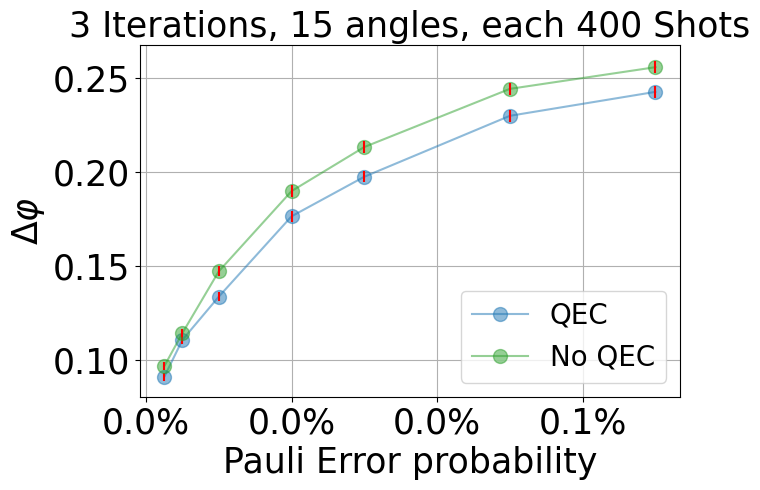

In [6]:
#x, y, y_qec, err, err_qec = [],[],[],[],[]
x, y, y_qec, err, err_qec = np.loadtxt("Files für Leon/FTSteane_BA_PS_QEC+PS.txt", delimiter = ",")


fig, ax1 = plt.subplots(figsize=(7,5))
ax1.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals = 1))

err = [i/((400)**0.5) for i in err]
err_qec = [i/((400)**0.5)for i in err_qec]

ax1.plot(x,y_qec, label="QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(x,y, label="No QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y, yerr=err, ecolor="red", linestyle="")

ax1.set_title("3 Iterations, 15 angles, each 400 Shots", fontsize=25)

ax1.set_xlabel("Pauli Error probability", fontsize=25)

ax1.set_ylabel(r"$\Delta \varphi$", fontsize=25)

ax1.tick_params(axis='both', which='major', labelsize=25)

ax1.grid()
ax1.legend(fontsize=20)

#fig.suptitle('Three iterations iQPE on a [12,2,4] Carbon Code', fontsize=20)
plt.tight_layout()

#plt.savefig("Figures/RotSurfFinal_4.png", dpi = 200)
plt.show()

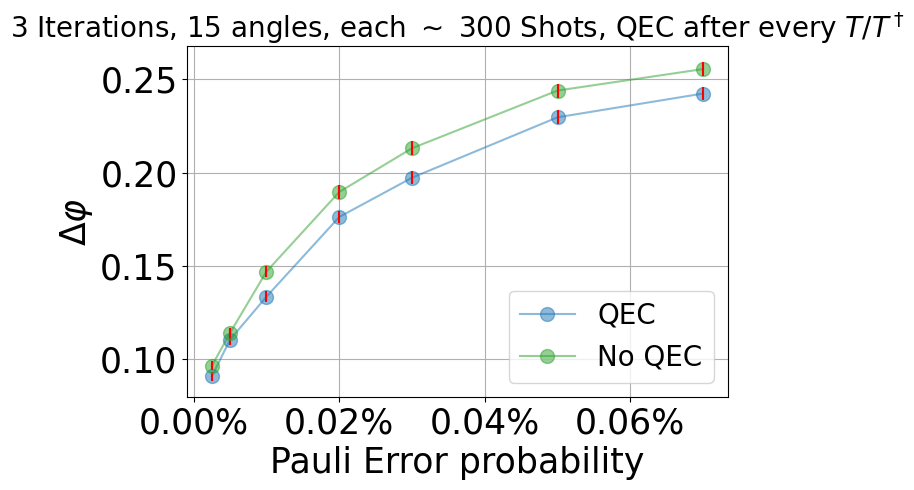

In [10]:
x, y, y_qec, err, err_qec = np.loadtxt("Files für Leon/FTSteane_BA_PS_QEC+PS.txt", delimiter = ",")


fig, ax1 = plt.subplots(figsize=(7,5))
ax1.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals = 2))

err = [i/((400-113)**0.5) for i in err]
err_qec = [i/((400-113)**0.5)for i in err_qec]

ax1.plot(x,y_qec, label="QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(x,y, label="No QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y, yerr=err, ecolor="red", linestyle="")


ax1.set_title(r"3 Iterations, 15 angles, each $\sim$ 300 Shots, QEC after every $T/T^\dagger$", fontsize=20)

ax1.set_xlabel("Pauli Error probability", fontsize=25)

ax1.set_ylabel(r"$\Delta \varphi$", fontsize=25)

ax1.tick_params(axis='both', which='major', labelsize=25)

ax1.grid()
ax1.legend(fontsize=20)

#fig.suptitle('Three iterations iQPE on a [12,2,4] Carbon Code', fontsize=20)
plt.tight_layout()
#plt.savefig("Figures/SteaneFinal4.png", dpi = 200)
plt.show()